# PERCOBAAN 2

Percobaan 2 ini bertujuan untuk mengklasifikasikan citra serat kayu jenis Nantu, Palapi, dan Uru menggunakan fitur tekstur berbasis Gray Level Co-occurrence Matrix (GLCM). Tahapan penelitian meliputi pengumpulan data, augmentasi, preprocessing, ekstraksi fitur, seleksi fitur, normalisasi, pelatihan model, dan evaluasi performa menggunakan tiga algoritma klasifikasi, yaitu Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN).

Pada percobaan ini citra melalui tiga proses utama, yaitu resize untuk menyeragamkan dimensi citra, konversi grayscale untuk mengubah citra RGB menjadi satu kanal intensitas sesuai kebutuhan GLCM, dan histogram equalization untuk meningkatkan kontras sehingga detail tekstur serat kayu lebih terlihat jelas.

Percobaan ini juga menerapkan optimasi pada proses klasifikasi melalui penyesuaian distribusi fitur dan parameter model, dengan fokus utama mengukur kemampuan fitur tekstur GLCM dalam membedakan karakteristik visual setiap jenis kayu.

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

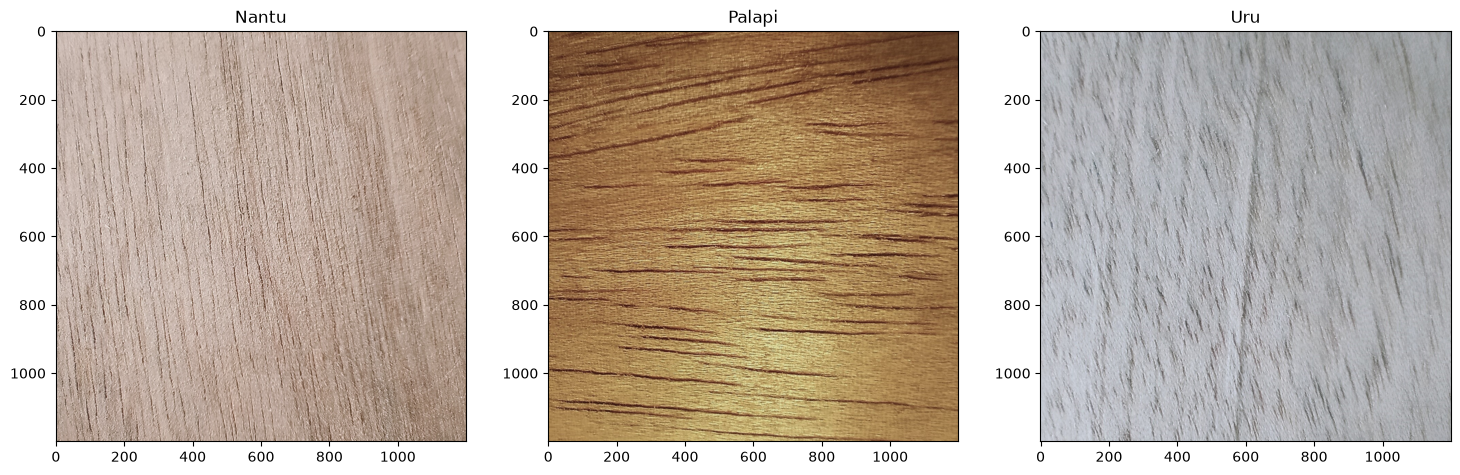

In [17]:
nantu = cv.imread(r"Dataset\Nantu\nantu_train (1).jpg")
nantu = cv.cvtColor(nantu, cv.COLOR_BGR2RGB)
palapi = cv.imread(r"Dataset\Palapi\palapi_train (1).jpg")
palapi = cv.cvtColor(palapi, cv.COLOR_BGR2RGB)
uru = cv.imread(r"Dataset\Uru\uru_train (1).jpg")
uru = cv.cvtColor(uru, cv.COLOR_BGR2RGB)

plt.figure(figsize=(18,7))


plt.subplot(1, 3, 1)
plt.title("Nantu")
plt.imshow(nantu)
plt.subplot(1, 3, 2)
plt.title("Palapi")
plt.imshow(palapi)
plt.subplot(1, 3, 3)
plt.title("Uru")
plt.imshow(uru)

## Load Data

Dataset terdiri dari citra serat kayu Nantu, Palapi, dan Uru yang tersimpan dalam tiga subfolder terpisah sesuai kelasnya. Program membaca setiap citra menggunakan OpenCV, lalu melakukan konversi ke grayscale dan resize ke ukuran seragam 256×256 piksel sebelum disimpan ke dalam array NumPy beserta label dan nama filenya. Folder yang tidak termasuk dalam daftar target akan dilewati secara otomatis.

Proses loading yang terstruktur ini penting untuk memastikan data yang masuk ke tahap berikutnya sudah bersih dan seragam. Ketidaksesuaian dimensi atau format citra antar kelas dapat menyebabkan ketidakkonsistenan dalam proses ekstraksi fitur, yang pada akhirnya berdampak pada performa model klasifikasi.

In [13]:
data = []
labels = []
file_name = []
dataset_dir = "Dataset"  

if os.path.exists(dataset_dir):
    for sub_folder in os.listdir(dataset_dir):
        sub_folder_path = os.path.join(dataset_dir, sub_folder)
        if not os.path.isdir(sub_folder_path):
            continue
            
        sub_folder_files = os.listdir(sub_folder_path)
        for i, filename in enumerate(sub_folder_files):
            img_path = os.path.join(sub_folder_path, filename)
            img = cv.imread(img_path)
            
            if img is not None:
                img = cv.resize(img, (128, 128))
                img = img.astype(np.uint8)
                img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
                
                data.append(img)
                labels.append(sub_folder)
                file_name.append(filename)
            else:
                print(f"Warning: Gagal membaca gambar {img_path}")

    data = np.array(data)
    labels = np.array(labels)
else:
    print(f"Direktori {dataset_dir} tidak ditemukan!")

## Data Augmentation

Augmentasi dilakukan untuk memperbanyak jumlah data dan menambah variasi citra tanpa perlu mengumpulkan data baru. Setiap citra asli menghasilkan tiga citra tambahan melalui tiga teknik, yaitu **flip horizontal**, **flip vertikal**, dan **Gaussian blur**. Flip horizontal dan vertikal mensimulasikan variasi orientasi serat kayu, sedangkan Gaussian blur mensimulasikan kondisi citra yang kurang tajam. Dengan demikian, setiap satu citra asli menghasilkan empat citra total, sehingga jumlah dataset meningkat empat kali lipat.

Augmentasi yang diterapkan dipilih karena relevan dengan karakteristik citra serat kayu, di mana pola tekstur kayu secara alami dapat muncul dari berbagai arah. Namun perlu diperhatikan bahwa teknik augmentasi yang terlalu seragam tetap berpotensi menghasilkan sampel yang kurang bervariasi, sehingga kontribusinya terhadap peningkatan performa model perlu diverifikasi melalui evaluasi lebih lanjut.

In [14]:
data_augmented = []
labels_augmented = []
file_name_augmented = []

for i in range(len(data)):
    img = data[i]
    label = labels[i]
    fname = file_name[i]
    
    # Citra Asli
    data_augmented.append(img)
    labels_augmented.append(label)
    file_name_augmented.append(fname)
    
    # 1. Flip Horizontal
    img_flip_h = cv.flip(img, 1)
    data_augmented.append(img_flip_h)
    labels_augmented.append(label)
    file_name_augmented.append('flip_h_' + fname)
    
    # 2. Flip Vertikal
    img_flip_v = cv.flip(img, 0)
    data_augmented.append(img_flip_v)
    labels_augmented.append(label)
    file_name_augmented.append('flip_v_' + fname)
    
    # 3. Blur (Gaussian)
    img_blur = cv.GaussianBlur(img, (5, 5), 0)
    data_augmented.append(img_blur)
    labels_augmented.append(label)
    file_name_augmented.append('blur_' + fname)

data_augmented = np.array(data_augmented)
labels_augmented = np.array(labels_augmented)

In [15]:
print("Data sebelum augmentasi: ", len(data))
print("Data setelah augmentasi: ", len(data_augmented))

Data sebelum augmentasi:  315
Data setelah augmentasi:  1260


## Preprocessing

Tahap preprocessing terdiri dari resize, konversi grayscale, median filtering, dan histogram equalization.

Tahapan ini dipilih untuk mempertahankan informasi tekstur sambil mengurangi noise dan meningkatkan kontras citra. Histogram Equalization membantu memperjelas pola serat kayu yang mungkin sulit dibedakan pada citra asli.

Kelebihan pendekatan ini adalah prosesnya sederhana dan relatif cepat. Namun, penggunaan grayscale menyebabkan informasi warna dihilangkan sehingga klasifikasi hanya bergantung pada tekstur. Jika warna kayu memiliki karakteristik yang berbeda antar kelas, informasi tersebut tidak dimanfaatkan oleh model.

In [16]:
def resize_img(image, target_size=(256, 256)):
    return cv.resize(image, target_size)

def grayscale_filter(image):
    if len(image.shape) == 3:
        return cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    return image

def histogram_equalization(image):
    return cv.equalizeHist(image)

def preprocess_image_v2(image, target_size=(128, 128)):
    """
    Pipeline Preprocessing V2:
    1. Resize
    2. Grayscale
    3. Histogram Equalization
    """
    img = resize_img(image, target_size)
    img = grayscale_filter(img)
    img = histogram_equalization(img)
    return img

In [17]:
print("Memulai preprocessing...")
data_preprocessed = np.array([preprocess_image_v2(img) for img in data_augmented])

print(f"Preprocessing selesai!")
print(f"Total data yang diproses: {len(data_preprocessed)}")
print(f"Bentuk data baru (shape): {data_preprocessed.shape}")

Memulai preprocessing...
Preprocessing selesai!
Total data yang diproses: 1260
Bentuk data baru (shape): (1260, 128, 128)


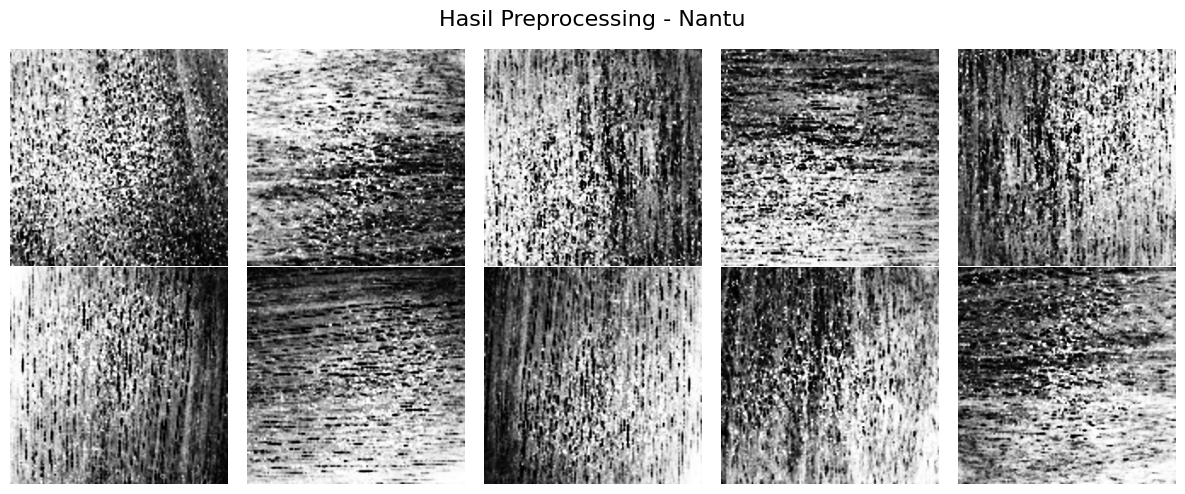

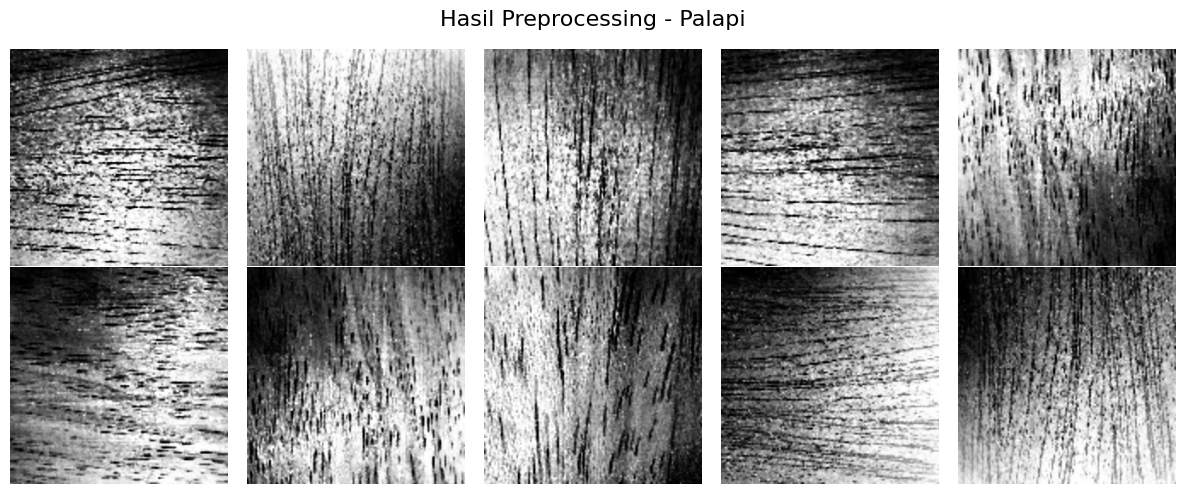

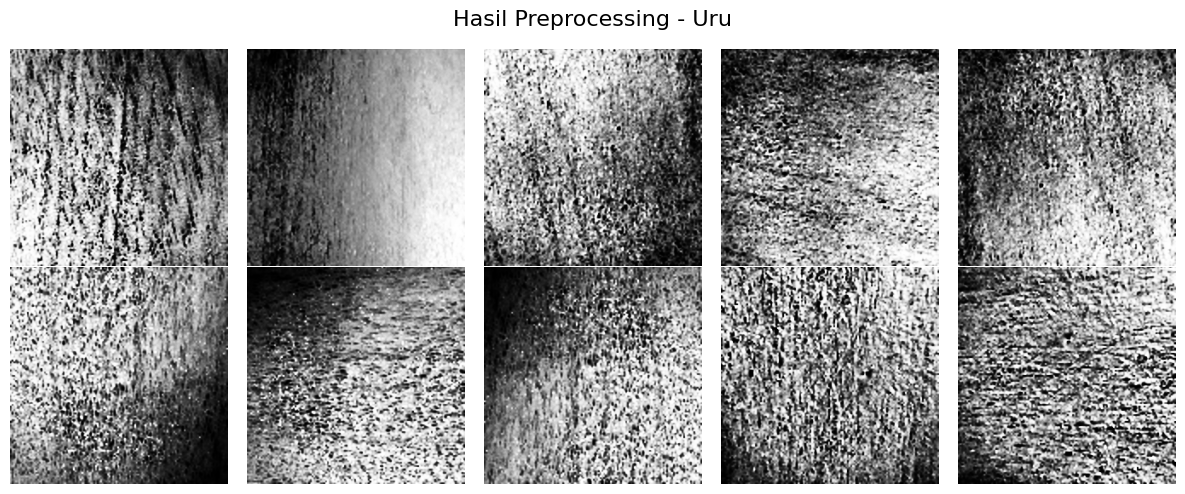

In [18]:
def percobaan2(img):
    img_resize = resize_img(img, (256, 256))
    img_gray = grayscale_filter(img_resize)
    img_histogram = histogram_equalization(img_gray)
    return img_histogram

dataPreprocessed = [percobaan2(img) for img in data]

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]
    
    fig, axs = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(f'Hasil Preprocessing - {label}', fontsize=16)
    
    for k in range(10):
        row = k // 5
        col = k % 5
        ax = axs[row][col]
        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9) 
    plt.show()

## Feature Extraction

Ekstraksi fitur dilakukan menggunakan Gray Level Co-occurrence Matrix (GLCM), yaitu metode yang merepresentasikan karakteristik tekstur citra berdasarkan hubungan spasial intensitas antar piksel. Matriks GLCM dihitung pada empat sudut orientasi, yaitu **0°, 45°, 90°, dan 135°**, dengan jarak piksel `distances=[1, 2, 3]` menggunakan pengaturan `symmetric=True` dan `normed=True`.

Dari setiap matriks GLCM yang dihasilkan, diekstrak tujuh fitur tekstur, yaitu **Contrast**, **Correlation**, **Energy**, **Homogeneity**, **Dissimilarity**, **ASM**, dan **Entropy**. Karena perhitungan dilakukan pada empat sudut, setiap fitur menghasilkan empat nilai berbeda sesuai orientasinya, sehingga total terdapat 28 fitur tekstur per citra.

Kelebihan GLCM terletak pada kemampuannya merepresentasikan tekstur secara kuantitatif dari berbagai arah, sehingga pola serat kayu yang memiliki orientasi berbeda tetap dapat tertangkap dengan baik. Namun, kualitas fitur yang dihasilkan sangat bergantung pada parameter yang digunakan serta kualitas preprocessing sebelumnya.

In [19]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm_matrix = graycomatrix(
    image,
    distances=[1,2,3],
    angles=angles,
    levels=256,
    symmetric=True,
    normed=True
)

    return glcm_matrix

In [20]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [21]:
for i in range(len(data_preprocessed)):
    data_preprocessed[i] = data_preprocessed[i].astype(np.uint8)

Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(data_preprocessed)):
    D0 = glcm(data_preprocessed[i], 0)
    D45 = glcm(data_preprocessed[i], 45)
    D90 = glcm(data_preprocessed[i], 90)
    D135 = glcm(data_preprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

print("--- Sukses membuat matriks GLCM untuk setiap sudut! ---")

--- Sukses membuat matriks GLCM untuk setiap sudut! ---


In [22]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(data_preprocessed)):
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

for i in range(len(data_preprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

for i in range(len(data_preprocessed)):
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

for i in range(len(data_preprocessed)):
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

for i in range(len(data_preprocessed)):
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

for i in range(len(data_preprocessed)):
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

for i in range(len(data_preprocessed)):
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

print("--- Ekstraksi fitur GLCM selesai untuk seluruh data! ---")

--- Ekstraksi fitur GLCM selesai untuk seluruh data! ---


## Penyimpanan Hasil Ekstraksi

Seluruh nilai fitur GLCM yang telah diekstrak dari keempat sudut orientasi disusun ke dalam sebuah DataFrame dengan 28 kolom fitur, mencakup Contrast, Dissimilarity, Homogeneity, Entropy, ASM, Energy, dan Correlation masing-masing pada sudut 0°, 45°, 90°, dan 135°. DataFrame tersebut kemudian dilengkapi dengan informasi nama file dan label kelas, lalu disimpan ke dalam file CSV bernama `hasil_ekstraksi_percobaan3.csv`.

Penyimpanan hasil ekstraksi dalam format CSV memungkinkan data fitur dapat diakses kembali kapan saja tanpa perlu mengulang proses komputasi GLCM dari awal, sehingga tahap pelatihan dan evaluasi model dapat dilakukan secara lebih efisien dan fleksibel.

In [23]:
dataTable = {
    'Filename': file_name_augmented,
    'Label': labels_augmented,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135
}

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan2.csv')
display(hasilEkstrak)

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,nantu_train (1).jpg,Nantu,8049.801058,8118.385889,6151.014272,8103.532333,0.023746,0.025019,0.036029,0.024388,...,0.000250,0.000213,0.014585,0.014608,0.015816,0.014595,0.261900,0.255849,0.435812,0.257160
1,flip_h_nantu_train (1).jpg,Nantu,8049.801058,8103.532333,6151.014272,8118.385889,0.023746,0.024388,0.036029,0.025019,...,0.000250,0.000213,0.014585,0.014595,0.015816,0.014608,0.261900,0.257160,0.435812,0.255849
2,flip_v_nantu_train (1).jpg,Nantu,8049.801058,8103.532333,6151.014272,8118.385889,0.023746,0.024388,0.036029,0.025019,...,0.000250,0.000213,0.014585,0.014595,0.015816,0.014608,0.261900,0.257160,0.435812,0.255849
3,blur_nantu_train (1).jpg,Nantu,678.880352,1208.523777,633.038201,1156.579453,0.122129,0.095235,0.133233,0.093256,...,0.001561,0.001138,0.038363,0.033801,0.039504,0.033737,0.937841,0.889197,0.941967,0.893943
4,nantu_train (10).jpg,Nantu,3776.299028,6484.103230,6536.499815,6548.122574,0.065881,0.042924,0.042768,0.042496,...,0.000638,0.000631,0.029467,0.025244,0.025255,0.025125,0.655329,0.407653,0.402651,0.401793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1255,blur_uru_train (98).jpg,Uru,47.884104,142.063922,104.266363,140.940852,0.256771,0.156978,0.186934,0.168599,...,0.000846,0.000735,0.034795,0.026700,0.029078,0.027115,0.995553,0.986743,0.990301,0.986846
1256,uru_train (99).jpg,Uru,2083.744525,2024.580569,1153.873954,2056.365057,0.043813,0.042880,0.067117,0.039235,...,0.000228,0.000167,0.012894,0.012968,0.015105,0.012936,0.807261,0.812278,0.893362,0.809326
1257,flip_h_uru_train (99).jpg,Uru,2083.744525,2056.365057,1153.873954,2024.580569,0.043813,0.039235,0.067117,0.042880,...,0.000228,0.000168,0.012894,0.012936,0.015105,0.012968,0.807261,0.809326,0.893362,0.812278
1258,flip_v_uru_train (99).jpg,Uru,2083.744525,2056.365057,1153.873954,2024.580569,0.043813,0.039235,0.067117,0.042880,...,0.000228,0.000168,0.012894,0.012936,0.015105,0.012968,0.807261,0.809326,0.893362,0.812278


## Seleksi Fitur

Seleksi Fitur dilakukan untuk menghilangkan fitur-fitur yang redundan, yaitu fitur yang memiliki korelasi terlalu tinggi satu sama lain sehingga dianggap membawa informasi yang serupa. Proses ini menggunakan metode **correlation-based feature selection** dengan threshold sebesar **0.90**, artinya apabila dua fitur memiliki nilai korelasi absolut ≥ 0.90, maka salah satu fitur akan dihapus dari dataset.

Hasil seleksi kemudian divisualisasikan menggunakan **heatmap korelasi** untuk memastikan bahwa fitur-fitur yang tersisa memiliki tingkat korelasi yang lebih rendah antar satu sama lain. Proses ini penting karena fitur yang terlalu berkorelasi dapat menyebabkan model menjadi tidak stabil dan memperlambat proses pelatihan tanpa memberikan tambahan informasi yang berarti.

Jumlah fitur sebelum seleksi: 28
Jumlah fitur setelah seleksi: 7


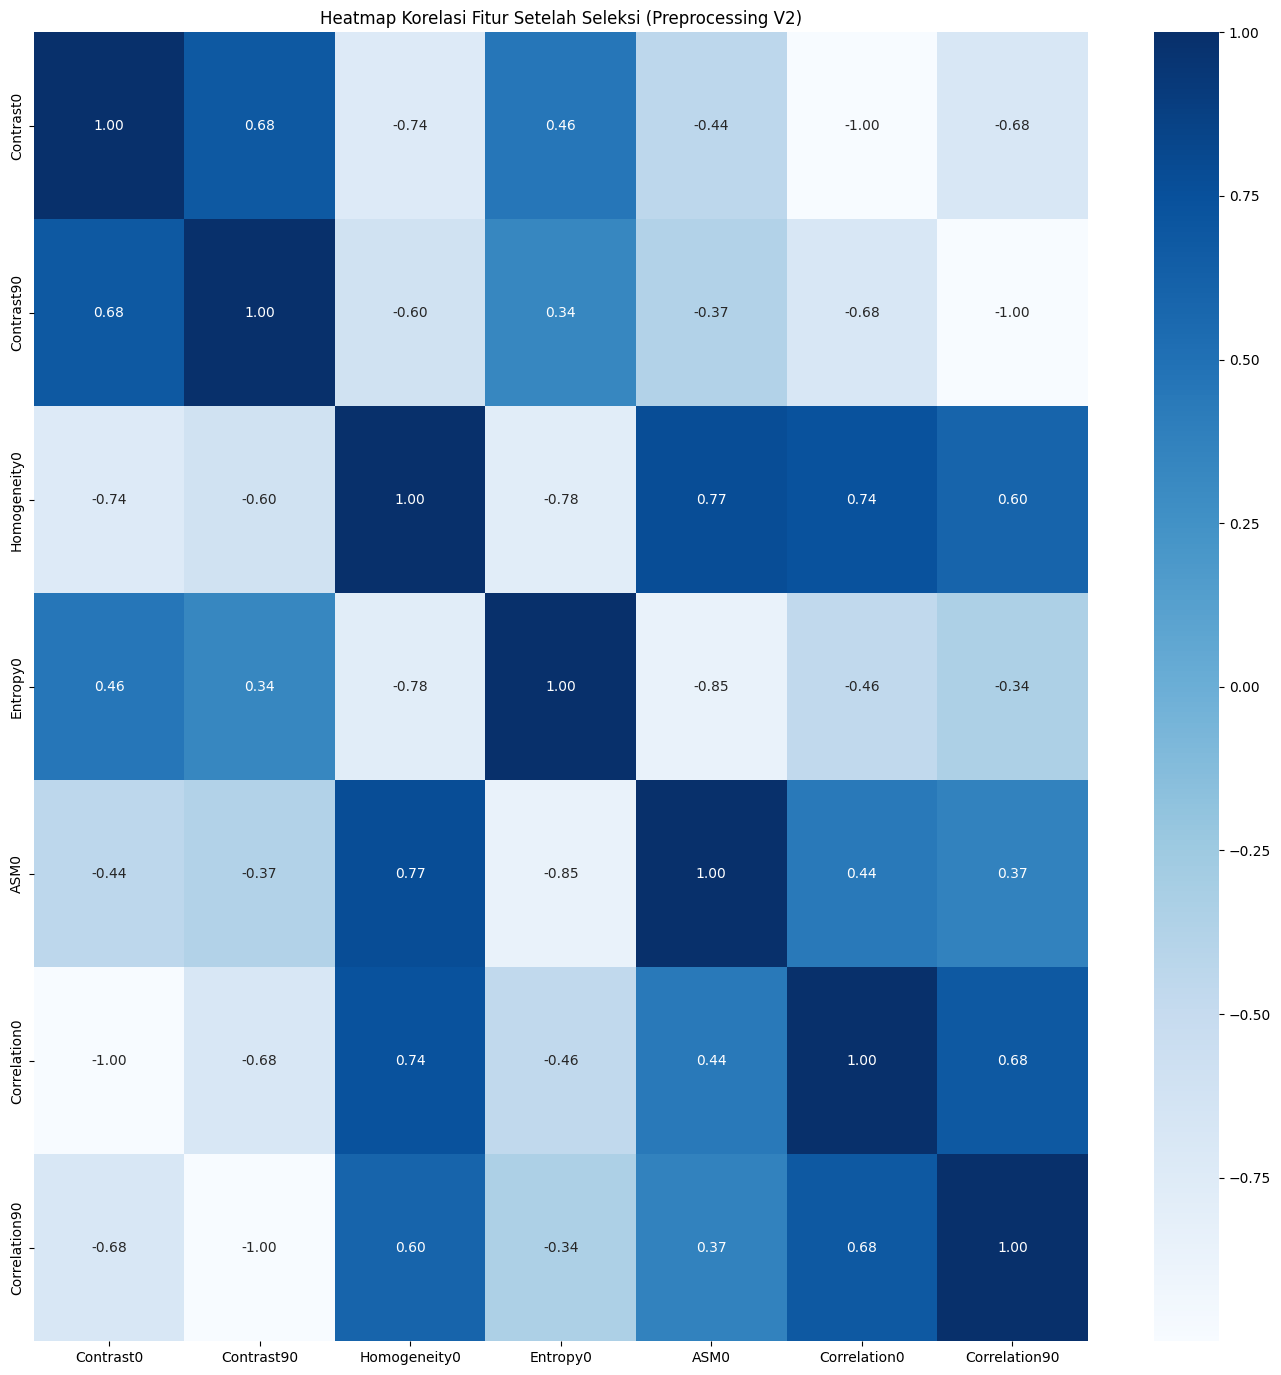

In [24]:
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.90
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Jumlah fitur sebelum seleksi: {correlation.shape[0]}")
print(f"Jumlah fitur setelah seleksi: {x_new.shape[1]}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur Setelah Seleksi (Preprocessing V2)')
plt.show()

## Splitting Data

Data fitur yang telah diseleksi dibagi menjadi dua subset menggunakan `train_test_split`, yaitu **data latih** sebesar 80% dan **data uji** sebesar 20%. Parameter `random_state=42` digunakan untuk memastikan hasil pembagian data konsisten setiap kali kode dijalankan. Selain itu, parameter `stratify=y` diterapkan untuk menjaga proporsi setiap kelas tetap seimbang antara data latih dan data uji, sehingga tidak terjadi ketimpangan distribusi label yang dapat mempengaruhi performa model.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1008, 7)
(252, 7)
(1008,)
(252,)


## Normalisasi

Kode ini menormalisasi fitur GLCM yang telah diekstrak dari citra serat kayu Nantu, Palapi, dan Uru menggunakan Z-score standardization. Karena ketujuh fitur GLCM seperti Contrast, Entropy, dan Correlation memiliki rentang nilai yang berbeda-beda secara signifikan, normalisasi diperlukan agar tidak ada satu fitur pun yang mendominasi proses pelatihan model hanya karena skala nilainya lebih besar.

Nilai rata-rata dan standar deviasi dihitung dari `X_train`, yaitu 80% data fitur hasil ekstraksi, kemudian nilai yang sama digunakan untuk menormalisasi `X_test` yang merupakan 20% sisanya. Pendekatan ini memastikan bahwa skala normalisasi konsisten antara data latih dan data uji, sehingga model dapat mengevaluasi citra serat kayu secara objektif tanpa terpengaruh informasi dari data uji.

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Modeling

Tiga model klasifikasi didefinisikan untuk membedakan karakteristik tekstur citra serat kayu Nantu, Palapi, dan Uru. **Random Forest** dibangun dengan 5 pohon keputusan, **SVM** menggunakan kernel RBF untuk menangani pola tekstur yang bersifat non-linear, dan **KNN** mengklasifikasikan citra berdasarkan 5 tetangga terdekat dalam ruang fitur GLCM.

Fungsi `generateClassificationReport` didefinisikan untuk menampilkan hasil evaluasi ketiga model secara seragam, mencakup **classification report** per kelas Nantu, Palapi, dan Uru, **confusion matrix** untuk melihat pola kesalahan klasifikasi antar kelas, serta nilai **accuracy** keseluruhan model.

In [27]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
svm = SVC(kernel='rbf', C=100, gamma='scale')
knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance'
)

### Train Random Forest Classifier

Data fitur dikonversi ke array NumPy dan di-reshape menjadi format dua dimensi agar kompatibel dengan model. Normalisasi Z-score kemudian diterapkan menggunakan rata-rata dan standar deviasi dari data latih, yang juga digunakan untuk menormalisasi data uji guna menghindari data leakage.

Model Random Forest dilatih menggunakan `rf.fit(X_train, y_train)` pada data fitur GLCM yang telah dinormalisasi. Evaluasi dilakukan pada dua subset, yaitu **training set** untuk mengukur seberapa baik model mempelajari data latih, dan **testing set** untuk mengukur kemampuan generalisasi model terhadap data yang belum pernah dilihat sebelumnya. Hasil evaluasi ditampilkan menggunakan fungsi `generateClassificationReport` yang mencakup classification report, confusion matrix, dan nilai accuracy untuk masing-masing subset.

In [28]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

       Nantu       1.00      1.00      1.00       336
      Palapi       1.00      1.00      1.00       336
         Uru       1.00      1.00      1.00       336

    accuracy                           1.00      1008
   macro avg       1.00      1.00      1.00      1008
weighted avg       1.00      1.00      1.00      1008

[[336   0   0]
 [  0 336   0]
 [  0   0 336]]
Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

       Nantu       0.94      0.93      0.93        84
      Palapi       0.93      0.93      0.93        84
         Uru       0.95      0.96      0.96        84

    accuracy                           0.94       252
   macro avg       0.94      0.94      0.94       252
weighted avg       0.94      0.94      0.94       252

[[78  5  1]
 [ 3 78  3]
 [ 2  1 81]]
Accuracy: 0.9404761904761905


### Train SVM Classifier

Model SVM dilatih menggunakan `svm.fit(X_train, y_train)` pada data fitur GLCM yang telah dinormalisasi sebelumnya. Evaluasi dilakukan pada dua subset, yaitu **training set** untuk mengukur kemampuan model dalam mempelajari pola tekstur data latih, dan **testing set** untuk mengukur kemampuan generalisasi model dalam mengklasifikasikan citra serat kayu Nantu, Palapi, dan Uru yang belum pernah dilihat sebelumnya. Hasil evaluasi keduanya ditampilkan menggunakan fungsi `generateClassificationReport` yang mencakup classification report, confusion matrix, dan nilai accuracy.

In [29]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

       Nantu       0.73      0.90      0.80       336
      Palapi       0.87      0.81      0.84       336
         Uru       0.90      0.75      0.82       336

    accuracy                           0.82      1008
   macro avg       0.83      0.82      0.82      1008
weighted avg       0.83      0.82      0.82      1008

[[303  16  17]
 [ 53 271  12]
 [ 61  23 252]]
Accuracy: 0.8194444444444444

------Testing Set------
              precision    recall  f1-score   support

       Nantu       0.66      0.83      0.74        84
      Palapi       0.82      0.70      0.76        84
         Uru       0.85      0.75      0.80        84

    accuracy                           0.76       252
   macro avg       0.78      0.76      0.76       252
weighted avg       0.78      0.76      0.76       252

[[70  8  6]
 [20 59  5]
 [16  5 63]]
Accuracy: 0.7619047619047619


### Train KNN Classifier

Model KNN menggunakan `knn.fit(X_train, y_train)` pada data fitur GLCM yang telah dinormalisasi. Evaluasi dilakukan pada dua subset, yaitu **training set** untuk mengukur seberapa baik model mengenali pola tekstur dari data latih, dan **testing set** untuk mengukur kemampuan model dalam mengklasifikasikan citra serat kayu Nantu, Palapi, dan Uru pada data yang belum pernah dilihat sebelumnya. Hasil evaluasi ditampilkan menggunakan fungsi `generateClassificationReport` yang mencakup classification report, confusion matrix, dan nilai accuracy.

In [30]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

       Nantu       1.00      1.00      1.00       336
      Palapi       1.00      1.00      1.00       336
         Uru       1.00      1.00      1.00       336

    accuracy                           1.00      1008
   macro avg       1.00      1.00      1.00      1008
weighted avg       1.00      1.00      1.00      1008

[[336   0   0]
 [  0 336   0]
 [  0   0 336]]
Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

       Nantu       0.92      0.90      0.91        84
      Palapi       0.93      0.93      0.93        84
         Uru       0.93      0.94      0.93        84

    accuracy                           0.92       252
   macro avg       0.92      0.92      0.92       252
weighted avg       0.92      0.92      0.92       252

[[76  4  4]
 [ 4 78  2]
 [ 3  2 79]]
Accuracy: 0.9246031746031746


### Evaluasi dengan Confusion Matriks

Fungsi `plot_confusion_matrix` didefinisikan untuk menampilkan confusion matrix dalam bentuk visual menggunakan `ConfusionMatrixDisplay` dengan warna biru. Confusion matrix divisualisasikan untuk ketiga model, yaitu **Random Forest**, **SVM**, dan **KNN**, masing-masing menggunakan hasil prediksi pada data uji.

Visualisasi ini memudahkan analisis pola kesalahan klasifikasi antar kelas Nantu, Palapi, dan Uru, seperti kelas mana yang sering tertukar satu sama lain, sehingga memberikan gambaran yang lebih intuitif dibandingkan hanya membaca nilai numerik dari classification report.

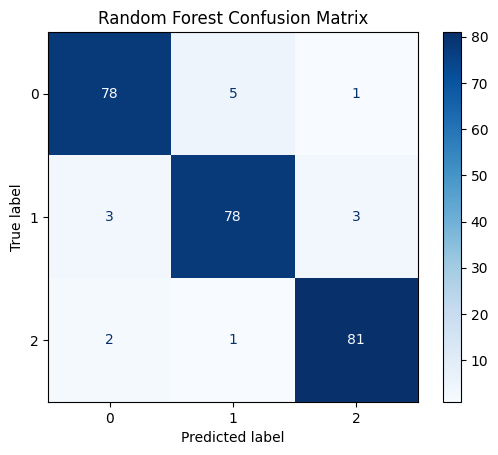

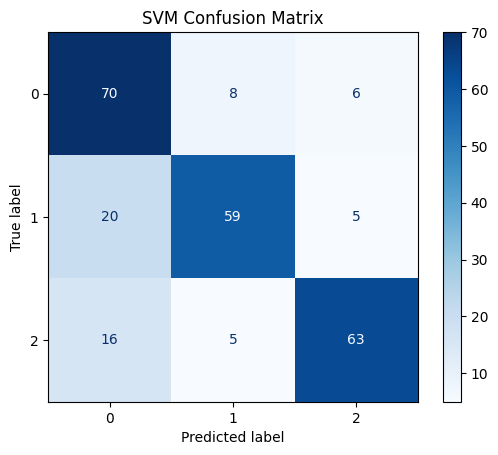

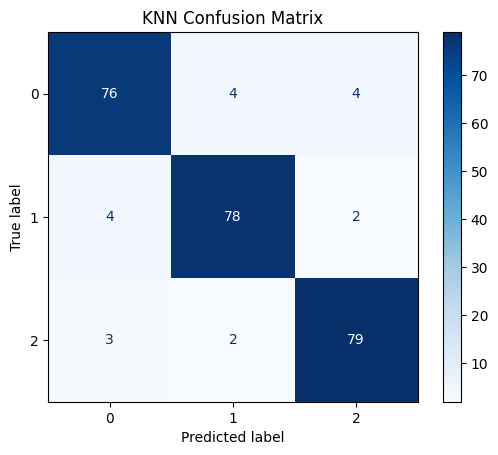

In [32]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

## Hasil Evaluasi Model

### Tabel Perbandingan Akurasi Training dan Testing Antar Percobaan

| Algoritma | Training P1 | Testing P1 | Training P2 | Testing P2 |
|-----------|------------|------------|------------|------------|
| Random Forest | 98.41% | 76.19% | 100.00% | **94.05%** |
| SVM | 62.70% | 47.62% | 81.94% | 76.19% |
| KNN | 84.13% | 60.32% | 100.00% | 92.46% |

### Tabel Perbandingan Metrik Evaluasi pada Data Testing Percobaan 2

| Algoritma | Precision | Recall | F1-Score | Accuracy |
|-----------|----------|--------|----------|----------|
| Random Forest | **0.94** | **0.94** | **0.94** | **94.05%** |
| SVM | 0.78 | 0.76 | 0.76 | 76.19% |
| KNN | 0.92 | 0.92 | 0.92 | 92.46% |

---

## Analisis Hasil

Berdasarkan hasil evaluasi yang dilakukan pada dua percobaan, dapat dilihat bahwa Percobaan 2 menghasilkan performa klasifikasi yang jauh lebih baik dibandingkan Percobaan 1. Peningkatan ini menunjukkan bahwa konfigurasi parameter dan proses pengolahan data yang digunakan pada Percobaan 2 mampu meningkatkan kemampuan model dalam mengenali pola tekstur citra kayu berdasarkan fitur GLCM.

Pada algoritma **Random Forest**, akurasi testing meningkat secara signifikan dari **76.19% pada Percobaan 1** menjadi **94.05% pada Percobaan 2**. Selain itu, akurasi training mencapai **100.00%**, yang menunjukkan bahwa model mampu mempelajari karakteristik data dengan sangat baik. Peningkatan ini kemungkinan disebabkan oleh penggunaan jumlah pohon (estimators) yang lebih banyak (`n_estimators=200`) serta teknik augmentasi data, sehingga model dapat menghasilkan keputusan yang lebih stabil dan akurat.

Pada algoritma **Support Vector Machine (SVM)**, terjadi peningkatan akurasi testing dari **47.62% pada Percobaan 1** menjadi **76.19% pada Percobaan 2**. Walaupun mengalami peningkatan yang cukup besar, performa SVM masih lebih rendah dibandingkan Random Forest dan KNN. Hal ini mengindikasikan bahwa pemisahan antar kelas pada fitur tekstur yang digunakan belum sepenuhnya optimal jika dimodelkan menggunakan hyperplane SVM.

Algoritma **K-Nearest Neighbor (KNN)** menunjukkan peningkatan performa yang paling signifikan. Akurasi testing meningkat dari **60.32% pada Percobaan 1** menjadi **92.46% pada Percobaan 2**. Selain itu, akurasi training mencapai **100.00%**, yang menunjukkan bahwa model mampu mengenali pola data dengan sangat baik. Penggunaan parameter yang lebih optimal pada Percobaan 2 (seperti `n_neighbors=3` dan pembobotan `weights='distance'`) serta normalisasi skala fitur dengan `StandardScaler` membuat proses pencarian tetangga terdekat menjadi lebih efektif dalam membedakan tekstur kayu Nantu, Palapi, dan Uru.

Jika dibandingkan secara keseluruhan, **Random Forest pada Percobaan 2 menghasilkan akurasi testing tertinggi sebesar 94.05%**, diikuti oleh **KNN sebesar 92.46%**, sedangkan **SVM memperoleh akurasi sebesar 76.19%**. Selisih akurasi antara Random Forest dan KNN hanya sekitar **1.59%**, namun Random Forest tetap menjadi model dengan performa terbaik berdasarkan hasil pengujian.

---

## Kesimpulan

Berdasarkan hasil perbandingan kedua percobaan, dapat disimpulkan bahwa **Percobaan 2 memberikan hasil klasifikasi terbaik dibandingkan Percobaan 1**. Dari seluruh model yang diuji, **Random Forest pada Percobaan 2 merupakan model dengan akurasi tertinggi, yaitu sebesar 94.05%**, sehingga dapat direkomendasikan sebagai model terbaik untuk klasifikasi citra serat kayu Nantu, Palapi, dan Uru berdasarkan fitur tekstur GLCM. KNN menempati posisi kedua dengan akurasi 92.46%, sedangkan SVM memiliki performa paling rendah dengan akurasi 76.19%.